# 🖼️ Image Caption Generator
**CNN (EfficientNetB0) + LSTM | Trained on 1000 Flickr8k images**

This notebook:
1. Downloads Flickr8k dataset (images + captions)
2. Extracts image features using EfficientNetB0
3. Trains an LSTM-based caption generator
4. Generates captions for new images

> ✅ Designed to run end-to-end on Google Colab (GPU recommended)

## Step 1: Install & Import Dependencies

In [4]:
# Install required packages
!pip install -q kaggle tensorflow pillow tqdm matplotlib nltk

In [5]:
import os
import re
import json
import pickle
import string
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

import nltk
nltk.download('punkt', quiet=True)

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: True


## Step 2: Download Flickr8k Dataset via Kaggle

You need a Kaggle API token. Go to https://www.kaggle.com/settings → API → Create New Token → upload `kaggle.json` below.

In [6]:
from google.colab import files

# Upload your kaggle.json here
print("Upload your kaggle.json file:")
uploaded = files.upload()

# Set up Kaggle credentials
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print("✅ Kaggle credentials set!")

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ Kaggle credentials set!


In [7]:
# Download Flickr8k dataset
!kaggle datasets download -d adityajn105/flickr8k -p /content/flickr8k --unzip -q
print("✅ Dataset downloaded!")
!ls /content/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
✅ Dataset downloaded!
captions.txt  Images


## Step 3: Load & Preprocess Captions

In [8]:
# Configuration
IMAGE_DIR = '/content/flickr8k/Images'
CAPTIONS_FILE = '/content/flickr8k/captions.txt'
MAX_IMAGES = 1000        # Limit to 1000 images for faster training
MAX_VOCAB_SIZE = 5000    # Keep top 5000 words
MAX_SEQ_LEN = 35         # Max caption length (tokens)
EMBED_DIM = 256
LSTM_UNITS = 256
BATCH_SIZE = 32
EPOCHS = 20
IMG_SIZE = (224, 224)

print("Configuration set ✅")

Configuration set ✅


In [9]:
def clean_caption(caption):
    """Lowercase, remove punctuation & numbers, strip extra spaces."""
    caption = caption.lower()
    caption = re.sub(r"[^a-z\s]", "", caption)
    caption = re.sub(r"\s+", " ", caption).strip()
    return caption

def load_captions(filepath, max_images=None):
    """Load captions from Flickr8k captions.txt file."""
    captions = {}
    with open(filepath, 'r') as f:
        lines = f.readlines()[1:]  # Skip header

    for line in lines:
        line = line.strip()
        if not line:
            continue
        parts = line.split(',', 1)
        if len(parts) != 2:
            continue
        img_name, caption = parts
        img_name = img_name.strip()
        caption = clean_caption(caption.strip())
        caption = 'startseq ' + caption + ' endseq'

        if img_name not in captions:
            captions[img_name] = []
        captions[img_name].append(caption)

    # Limit to max_images unique images
    if max_images:
        keys = list(captions.keys())[:max_images]
        captions = {k: captions[k] for k in keys}

    return captions

captions_dict = load_captions(CAPTIONS_FILE, MAX_IMAGES)
print(f"✅ Loaded captions for {len(captions_dict)} images")
print(f"\nSample image: {list(captions_dict.keys())[0]}")
print(f"Sample captions:")
for cap in list(captions_dict.values())[0]:
    print(f"  - {cap}")

✅ Loaded captions for 1000 images

Sample image: 1000268201_693b08cb0e.jpg
Sample captions:
  - startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq
  - startseq a girl going into a wooden building endseq
  - startseq a little girl climbing into a wooden playhouse endseq
  - startseq a little girl climbing the stairs to her playhouse endseq
  - startseq a little girl in a pink dress going into a wooden cabin endseq


## Step 4: Build Vocabulary

In [10]:
# Collect all words
all_words = []
for caps in captions_dict.values():
    for cap in caps:
        all_words.extend(cap.split())

word_freq = Counter(all_words)
print(f"Total unique words: {len(word_freq)}")

# Keep top N words
vocab = ['<pad>', '<unk>'] + [w for w, _ in word_freq.most_common(MAX_VOCAB_SIZE - 2)]
# Ensure special tokens are included
for tok in ['startseq', 'endseq']:
    if tok not in vocab:
        vocab.append(tok)

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
vocab_size = len(vocab)

print(f"Vocabulary size: {vocab_size}")
print(f"Sample vocab: {vocab[2:12]}")

Total unique words: 3268
Vocabulary size: 3270
Sample vocab: ['a', 'startseq', 'endseq', 'in', 'the', 'on', 'is', 'and', 'dog', 'with']


## Step 5: Extract Image Features with EfficientNetB0

In [11]:
# Build feature extractor (no top classification layer)
base_model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')
feature_extractor = keras.Model(inputs=base_model.input, outputs=base_model.output)
feature_extractor.trainable = False

print(f"Feature vector size: {feature_extractor.output_shape[-1]}")

def load_and_preprocess_image(img_path):
    """Load image, resize, and preprocess for EfficientNet."""
    img = Image.open(img_path).convert('RGB')
    img = img.resize(IMG_SIZE)
    img = np.array(img, dtype=np.float32)
    img = preprocess_input(img)
    return img

def extract_features(captions_dict, image_dir, batch_size=32):
    """Extract CNN features for all images in batches."""
    img_names = list(captions_dict.keys())
    features = {}

    for i in tqdm(range(0, len(img_names), batch_size), desc="Extracting features"):
        batch_names = img_names[i:i+batch_size]
        batch_imgs = []
        valid_names = []

        for name in batch_names:
            path = os.path.join(image_dir, name)
            if os.path.exists(path):
                try:
                    img = load_and_preprocess_image(path)
                    batch_imgs.append(img)
                    valid_names.append(name)
                except Exception as e:
                    print(f"Skipping {name}: {e}")

        if batch_imgs:
            batch_arr = np.array(batch_imgs)
            feats = feature_extractor.predict(batch_arr, verbose=0)
            for name, feat in zip(valid_names, feats):
                features[name] = feat

    return features

print("Extracting image features (this may take a few minutes)...")
image_features = extract_features(captions_dict, IMAGE_DIR)
print(f"\n✅ Extracted features for {len(image_features)} images")
print(f"Feature shape: {list(image_features.values())[0].shape}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature vector size: 1280
Extracting image features (this may take a few minutes)...


Extracting features: 100%|██████████| 32/32 [00:52<00:00,  1.63s/it]


✅ Extracted features for 1000 images
Feature shape: (1280,)


## Step 6: Prepare Training Data

In [12]:
def caption_to_ids(caption, word2idx, max_len):
    """Convert caption string to list of word IDs, truncated to max_len."""
    words = caption.split()
    ids = [word2idx.get(w, word2idx['<unk>']) for w in words]
    return ids[:max_len]

def create_sequences(captions_dict, image_features, word2idx, max_len):
    """Create (img_feature, input_seq, target_word) triples."""
    X_img, X_seq, y = [], [], []

    for img_name, caps in captions_dict.items():
        if img_name not in image_features:
            continue
        feat = image_features[img_name]

        for cap in caps:
            ids = caption_to_ids(cap, word2idx, max_len)
            # Teacher forcing: predict next word at each step
            for t in range(1, len(ids)):
                in_seq = ids[:t]
                out_word = ids[t]
                in_seq_padded = pad_sequences([in_seq], maxlen=max_len, padding='post')[0]
                X_img.append(feat)
                X_seq.append(in_seq_padded)
                y.append(out_word)

    return np.array(X_img), np.array(X_seq), np.array(y)

print("Creating training sequences...")
X_img, X_seq, y = create_sequences(captions_dict, image_features, word2idx, MAX_SEQ_LEN)

print(f"✅ Training samples: {len(X_img)}")
print(f"Image feature shape: {X_img.shape}")
print(f"Sequence shape: {X_seq.shape}")
print(f"Target shape: {y.shape}")

Creating training sequences...
✅ Training samples: 60028
Image feature shape: (60028, 1280)
Sequence shape: (60028, 35)
Target shape: (60028,)


## Step 7: Build CNN+LSTM Caption Model

In [13]:
def build_caption_model(vocab_size, max_seq_len, feature_dim, embed_dim, lstm_units):
    """
    Merge model:
    - Image branch: Dense projection of CNN features
    - Text branch:  Embedding -> LSTM
    - Merge: Add -> Dense -> Softmax
    """
    # Image feature input
    img_input = layers.Input(shape=(feature_dim,), name='image_input')
    img_dense = layers.Dense(embed_dim, activation='relu', name='img_dense')(img_input)
    img_repeat = layers.RepeatVector(1)(img_dense)  # shape: (1, embed_dim)

    # Sequence input
    seq_input = layers.Input(shape=(max_seq_len,), name='seq_input')
    seq_embed = layers.Embedding(vocab_size, embed_dim, mask_zero=False, name='embedding')(seq_input)

    # Concatenate image context with sequence
    merged = layers.Concatenate(axis=1)([img_repeat, seq_embed])  # (1+max_seq_len, embed_dim)
    lstm_out = layers.LSTM(lstm_units, name='lstm')(merged)
    lstm_out = layers.Dropout(0.4)(lstm_out)

    # Output layer
    output = layers.Dense(vocab_size, activation='softmax', name='output')(lstm_out)

    model = keras.Model(inputs=[img_input, seq_input], outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

FEATURE_DIM = list(image_features.values())[0].shape[0]

model = build_caption_model(
    vocab_size=vocab_size,
    max_seq_len=MAX_SEQ_LEN,
    feature_dim=FEATURE_DIM,
    embed_dim=EMBED_DIM,
    lstm_units=LSTM_UNITS
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_dense (Dense)   │ (None, 256)       │    327,936 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_input           │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 1, 256)    │          0 │ img_dense[0][0]   │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 35, 256)   │    837,120 │ seq_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 36, 256)   │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3270)      │    840,390 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,530,758 (9.65 MB)

 Trainable params: 2,530,758 (9.65 MB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train the Model

In [14]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint('/content/best_caption_model.keras', monitor='val_loss',
                                    save_best_only=True, verbose=1)
]

print(f"Training on {len(X_img)} samples for up to {EPOCHS} epochs...")

history = model.fit(
    [X_img, X_seq], y,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    callbacks=callbacks,
    shuffle=True
)

Training on 60028 samples for up to 20 epochs...
Epoch 1/20
1684/1689 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1325 - loss: 5.5483
Epoch 1: val_loss improved from None to 5.40236, saving model to /content/best_caption_model.keras

Epoch 1: finished saving model to /content/best_caption_model.keras
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.1347 - loss: 5.4063 - val_accuracy: 0.1348 - val_loss: 5.4024 - learning_rate: 0.0010
Epoch 2/20
1684/1689 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1347 - loss: 5.2946
Epoch 2: val_loss did not improve from 5.40236
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.1352 - loss: 5.3058 - val_accuracy: 0.1348 - val_loss: 5.4473 - learning_rate: 0.0010
Epoch 3/20
1684/1689 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1347 - loss: 5.2740
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 5.40236
1689/1689 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.1

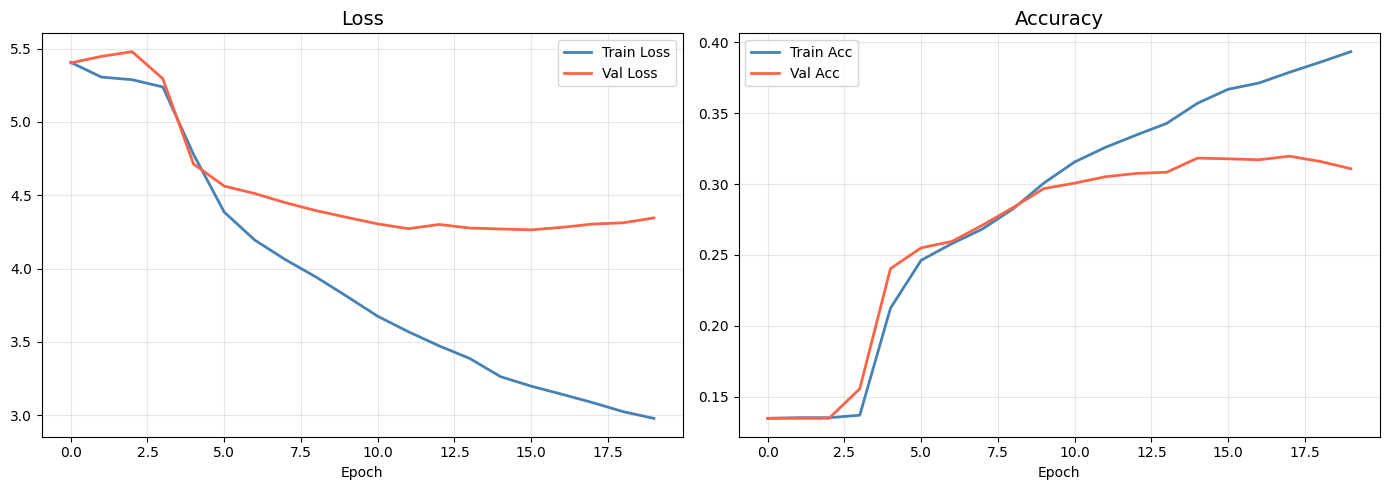

✅ Training complete!


In [15]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Val Loss', color='tomato', linewidth=2)
ax1.set_title('Loss', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['accuracy'], label='Train Acc', color='steelblue', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Val Acc', color='tomato', linewidth=2)
ax2.set_title('Accuracy', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150)
plt.show()
print("✅ Training complete!")

## Step 9: Generate Captions

In [16]:
def generate_caption(model, feature_extractor, image_path, word2idx, idx2word,
                     max_len=MAX_SEQ_LEN, temperature=1.0):
    """
    Generate a caption for a given image.
    temperature > 1 = more creative; temperature < 1 = more conservative.
    """
    # Extract features
    img = load_and_preprocess_image(image_path)
    img = np.expand_dims(img, axis=0)
    feature = feature_extractor.predict(img, verbose=0)

    # Start with startseq
    in_seq = [word2idx.get('startseq', 0)]
    result = []

    for _ in range(max_len):
        padded = pad_sequences([in_seq], maxlen=max_len, padding='post')
        preds = model.predict([feature, padded], verbose=0)[0]

        # Temperature sampling
        preds = np.log(preds + 1e-9) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        word_id = np.random.choice(len(preds), p=preds)

        word = idx2word.get(word_id, '<unk>')
        if word == 'endseq':
            break
        if word not in ('startseq', '<pad>', '<unk>'):
            result.append(word)
        in_seq.append(word_id)

    return ' '.join(result)

def greedy_caption(model, feature_extractor, image_path, word2idx, idx2word, max_len=MAX_SEQ_LEN):
    """Generate caption using greedy (argmax) decoding."""
    img = load_and_preprocess_image(image_path)
    img = np.expand_dims(img, axis=0)
    feature = feature_extractor.predict(img, verbose=0)

    in_seq = [word2idx.get('startseq', 0)]
    result = []

    for _ in range(max_len):
        padded = pad_sequences([in_seq], maxlen=max_len, padding='post')
        preds = model.predict([feature, padded], verbose=0)[0]
        word_id = np.argmax(preds)
        word = idx2word.get(word_id, '<unk>')
        if word == 'endseq':
            break
        if word not in ('startseq', '<pad>', '<unk>'):
            result.append(word)
        in_seq.append(word_id)

    return ' '.join(result)

print("✅ Caption generation functions ready!")

✅ Caption generation functions ready!


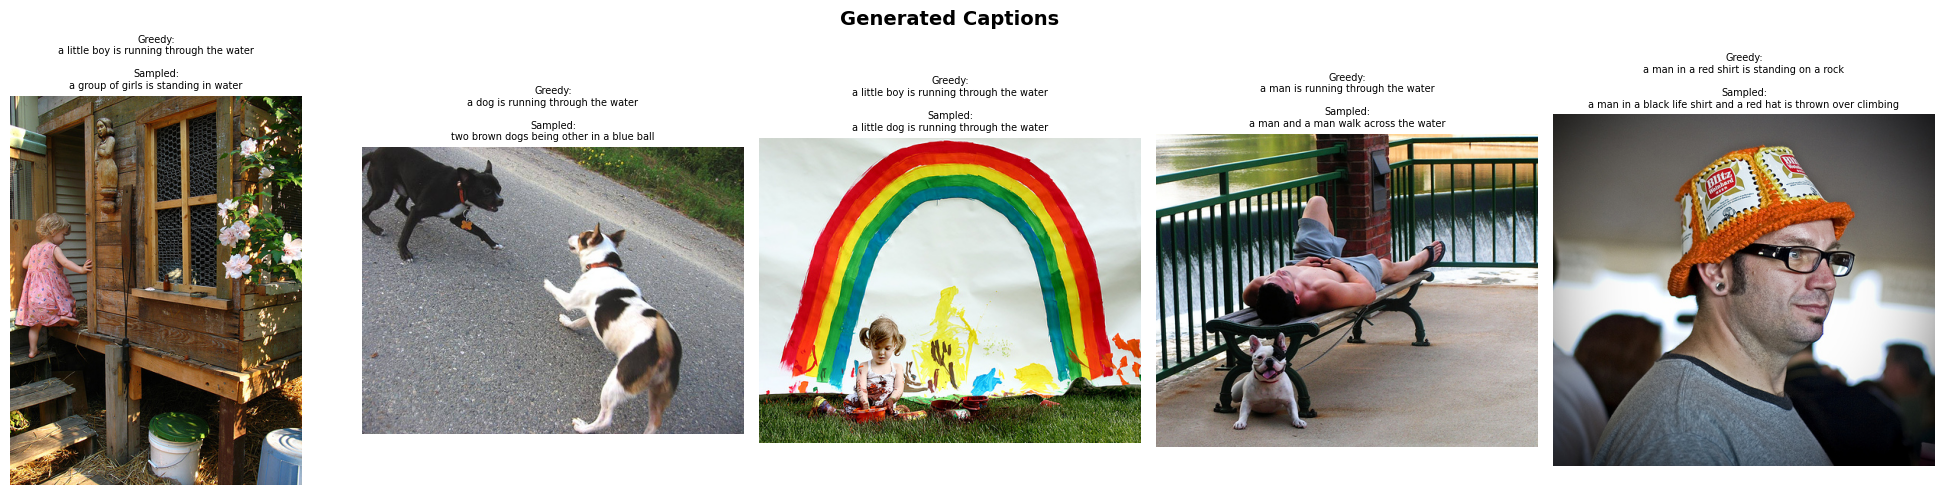

In [17]:
# Test on images from the training set
test_images = list(captions_dict.keys())[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, img_name in zip(axes, test_images):
    img_path = os.path.join(IMAGE_DIR, img_name)
    if not os.path.exists(img_path):
        continue

    greedy = greedy_caption(model, feature_extractor, img_path, word2idx, idx2word)
    sampled = generate_caption(model, feature_extractor, img_path, word2idx, idx2word, temperature=0.8)

    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"Greedy:\n{greedy}\n\nSampled:\n{sampled}",
                 fontsize=7, wrap=True)
    ax.axis('off')

plt.suptitle('Generated Captions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_captions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Caption Your Own Image

Upload any image to generate a caption:


Saving wp3846442-dio-brando-wallpapers.png to wp3846442-dio-brando-wallpapers.png


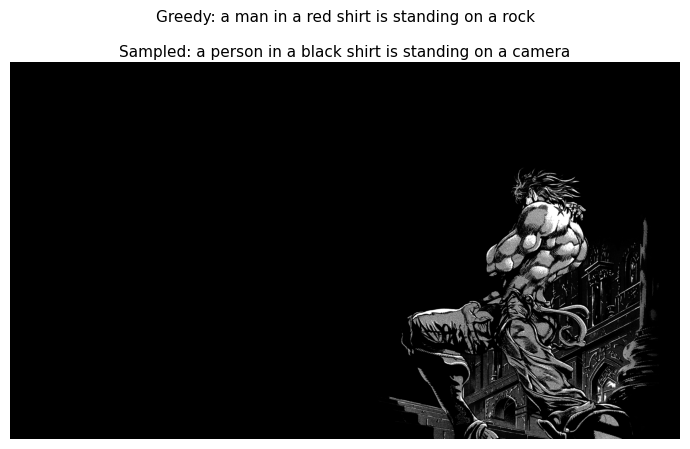


📸 Image: wp3846442-dio-brando-wallpapers.png
🔵 Greedy caption:  a man in a red shirt is standing on a rock
🟣 Sampled caption: a person in a black shirt is standing on a camera


In [18]:
from google.colab import files

print("Upload any image to generate a caption:")
uploaded = files.upload()

for fname in uploaded:
    img_path = f'/content/{fname}'
    with open(img_path, 'wb') as f:
        f.write(uploaded[fname])

    greedy = greedy_caption(model, feature_extractor, img_path, word2idx, idx2word)
    sampled = generate_caption(model, feature_extractor, img_path, word2idx, idx2word, temperature=0.7)

    img = Image.open(img_path)
    plt.figure(figsize=(7, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Greedy: {greedy}\n\nSampled: {sampled}", fontsize=11, wrap=True)
    plt.tight_layout()
    plt.show()

    print(f"\n📸 Image: {fname}")
    print(f"🔵 Greedy caption:  {greedy}")
    print(f"🟣 Sampled caption: {sampled}")

## Step 11: Save Everything

In [20]:
# Save model
model.save('/content/caption_model_final.keras')

# Save vocabulary
with open('/content/word2idx.json', 'w') as f:
    json.dump(word2idx, f)
with open('/content/idx2word.json', 'w') as f:
    json.dump({str(k): v for k, v in idx2word.items()}, f)

# Save image features (optional, speeds up future runs)
with open('/content/image_features.pkl', 'wb') as f:
    pickle.dump(image_features, f)

print("✅ Saved:")
print("  /content/caption_model_final.keras")
print("  /content/word2idx.json")
print("  /content/idx2word.json")
print("  /content/image_features.pkl")

# Download outputs
from google.colab import files
files.download('/content/caption_model_final.keras')
files.download('/content/word2idx.json')
files.download('/content/idx2word.json')

✅ Saved:
  /content/caption_model_final.keras
  /content/word2idx.json
  /content/idx2word.json
  /content/image_features.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📊 Summary

| Component | Detail |
|-----------|--------|
| Dataset | Flickr8k (1000 images) |
| Feature Extractor | EfficientNetB0 (ImageNet, frozen) |
| Caption Model | Merge (Image Dense + LSTM) |
| Vocabulary | Top 5000 words |
| Max Caption Length | 35 tokens |
| Decoding | Greedy + Temperature Sampling |

**Tips to improve quality:**
- Use all 8000 Flickr8k images (remove `MAX_IMAGES` limit)
- Try Flickr30k or MS-COCO for more data
- Increase `LSTM_UNITS` to 512 and `EMBED_DIM` to 512
- Fine-tune the last few EfficientNet layers
- Try Beam Search decoding instead of greedy/sampling